# Horizon-Conditioned Subgoal Proposer

Train a flow-matching subgoal proposer that samples the state representation reached `n` dataset steps in the future. The horizon `n` is passed into the network, so the same model can propose short- and long-range subgoals at inference time.


In [1]:
from __future__ import annotations

import os
import pickle
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import flax
import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from tqdm.auto import trange

from utils.datasets import CGCDataset
from utils.flax_utils import TrainState, nonpytree_field, save_agent
from utils.networks import ActorVectorField, MLP
from wrappers.datafuncs_utils import make_env_and_datasets


/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [2]:
config = dict(
    env_name='humanoidmaze-large-navigate-v0',
    dataset_path='../../scratch/data/humanoidmaze-large-navigate-v0/humanoidmaze-large-navigate-v0seed-0.npz',
    observations_key='oracle_reps',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    batch_size=256,
    num_train_steps=50_000,
    log_interval=500,
    seed=0,
    min_horizon_steps=1,
    max_horizon_steps=1_000,
    flow_steps=10,
    goal_conditioned=False,
    observation_conditioned=False,
    output_dir='checkpoints/horizon_subgoal_proposer',
)

config['horizon_scale'] = float(config['max_horizon_steps'])


The dataset wrapper samples an index `i`, samples or accepts a horizon `n`, then trains against the oracle representation at `min(i + n, episode_end)`. If `goal_conditioned=True`, it also passes the trajectory terminal representation as a goal.


In [3]:
@dataclass
class HorizonSubgoalDataset:
    dataset: Any
    config: dict[str, Any]

    def __post_init__(self):
        self.size = self.dataset.size
        self.observations_key = self.config['observations_key']
        self.min_horizon = int(self.config['min_horizon_steps'])
        self.max_horizon = int(self.config['max_horizon_steps'])
        self.goal_conditioned = bool(self.config.get('goal_conditioned', False))
        self.terminal_locs = np.asarray(self.dataset.terminal_locs)

    def get_reps(self, idxs):
        if self.observations_key in self.dataset:
            return np.asarray(self.dataset[self.observations_key][idxs])
        return np.asarray(self.dataset['observations'][idxs])

    def sample_horizons(self, batch_size):
        return np.random.randint(self.min_horizon, self.max_horizon + 1, size=batch_size, dtype=np.int32)

    def sample(self, batch_size: int, idxs=None, horizons=None):
        if idxs is None:
            idxs = self.dataset.get_random_idxs(batch_size)
        idxs = np.asarray(idxs, dtype=np.int64)
        batch_size = len(idxs)

        if horizons is None:
            horizons = self.sample_horizons(batch_size)
        horizons = np.asarray(horizons, dtype=np.int32).reshape(batch_size)

        final_state_idxs = self.terminal_locs[np.searchsorted(self.terminal_locs, idxs)]
        target_idxs = np.minimum(idxs + horizons, final_state_idxs)
        offsets = target_idxs - idxs

        raw_batch = self.dataset.sample(batch_size, idxs)
        batch = dict(raw_batch)
        batch['observations_for_proposer'] = np.asarray(raw_batch[self.observations_key])
        batch['target_subgoals'] = self.get_reps(target_idxs)
        batch['horizons'] = horizons.astype(np.float32)[:, None]
        batch['horizon_offsets'] = offsets.astype(np.float32)[:, None]
        batch['idxs'] = idxs
        batch['target_idxs'] = target_idxs
        batch['final_state_idxs'] = final_state_idxs

        if self.goal_conditioned:
            batch['goals'] = self.get_reps(final_state_idxs)

        return batch


In [4]:
def encode_horizons(horizons, horizon_scale):
    horizons = jnp.asarray(horizons, dtype=jnp.float32)
    if horizons.ndim == 1:
        horizons = horizons[:, None]
    linear = horizons / horizon_scale
    log_linear = jnp.log1p(horizons) / jnp.log1p(horizon_scale)
    return jnp.concatenate([linear, log_linear], axis=-1)


class HorizonConditionedVectorField(nn.Module):
    hidden_dims: tuple[int, ...]
    subgoal_dim: int
    horizon_scale: float
    layer_norm: bool = True

    @nn.compact
    def __call__(self, observations, actions, horizons, goals=None, times=None):
        inputs = [observations]
        if goals is not None:
            inputs.append(goals)
        inputs.extend([encode_horizons(horizons, self.horizon_scale), actions])
        if times is not None:
            inputs.append(times)

        x = jnp.concatenate(inputs, axis=-1)
        return MLP((*self.hidden_dims, self.subgoal_dim), activate_final=False, layer_norm=self.layer_norm)(x)


In [5]:
class HorizonSubgoalProposerAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def flow_loss(self, batch, grad_params=None, rng=None):
        observations = batch['observations_for_proposer']
        goals = batch.get('goals')
        horizons = batch['horizons']
        target_subgoals = batch['target_subgoals']

        batch_size, subgoal_dim = target_subgoals.shape
        rng = self.rng if rng is None else rng
        x_rng, t_rng = jax.random.split(rng)

        x_0 = jax.random.normal(x_rng, (batch_size, subgoal_dim))
        t = jax.random.uniform(t_rng, (batch_size, 1))
        x_t = (1.0 - t) * x_0 + t * target_subgoals
        target_velocity = target_subgoals - x_0

        pred_velocity = self.network(
            observations,
            actions=x_t,
            horizons=horizons,
            goals=goals,
            times=t,
            params=grad_params,
        )
        loss = jnp.mean(jnp.square(pred_velocity - target_velocity))
        mae = jnp.mean(jnp.abs(pred_velocity - target_velocity))
        endpoint_mse = jnp.mean(jnp.square((x_t + (1.0 - t) * pred_velocity) - target_subgoals))
        return loss, dict(flow_loss=loss, velocity_mae=mae, endpoint_mse=endpoint_mse)

    @jax.jit
    def update(self, batch):
        new_rng, loss_rng = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.flow_loss(batch, grad_params=grad_params, rng=loss_rng)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    @jax.jit
    def _sample_subgoals(self, observations, horizons, goals, rng):
        x = jax.random.normal(rng, (observations.shape[0], self.config['subgoal_dim']))
        for i in range(self.config['flow_steps']):
            t = jnp.full((observations.shape[0], 1), i / self.config['flow_steps'])
            vels = self.network(observations, actions=x, horizons=horizons, goals=goals, times=t)
            x = x + vels / self.config['flow_steps']
        return x

    def sample_subgoals(self, observations, horizons, rng, goals=None, num_samples=1):
        observations = np.asarray(observations, dtype=np.float32)
        single_observation = observations.ndim == 1
        if single_observation:
            observations = np.repeat(observations[None], num_samples, axis=0)

        batch_size = observations.shape[0]
        horizons = np.asarray(horizons, dtype=np.float32)
        if horizons.ndim == 0:
            horizons = np.full((batch_size, 1), float(horizons), dtype=np.float32)
        elif horizons.ndim == 1:
            horizons = horizons[:, None]

        if goals is not None:
            goals = np.asarray(goals, dtype=np.float32)
            if goals.ndim == 1:
                goals = np.repeat(goals[None], batch_size, axis=0)

        samples = self._sample_subgoals(observations, horizons, goals, rng)
        if single_observation and num_samples == 1:
            return samples[0]
        return samples

    @classmethod
    def create(cls, seed, example_batch, config):
        config = dict(config)
        rng = jax.random.PRNGKey(seed)
        rng, init_rng = jax.random.split(rng)
        subgoal_dim = example_batch['target_subgoals'].shape[-1]
        model = HorizonConditionedVectorField(
            hidden_dims=tuple(config['hidden_dims']),
            subgoal_dim=subgoal_dim,
            horizon_scale=float(config['horizon_scale']),
            layer_norm=bool(config['layer_norm']),
        )
        params = model.init(
            init_rng,
            example_batch['observations_for_proposer'],
            actions=example_batch['target_subgoals'],
            horizons=example_batch['horizons'],
            goals=example_batch.get('goals'),
            times=jnp.zeros_like(example_batch['horizons']),
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        config['subgoal_dim'] = subgoal_dim
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))


In [6]:
env, base_train_dataset, val_dataset = make_env_and_datasets(
    config['env_name'],
    dataset_path=config['dataset_path'],
    use_oracle_reps=True,
)
train_dataset = HorizonSubgoalDataset(base_train_dataset, config=config)

example_batch = train_dataset.sample(config['batch_size'])
print('env:', env.spec.id)
print('dataset keys:', sorted(base_train_dataset.keys()))
print('observation batch:', example_batch['observations_for_proposer'].shape)
print('target subgoal batch:', example_batch['target_subgoals'].shape)
print('horizon range:', float(example_batch['horizons'].min()), float(example_batch['horizons'].max()))


env: humanoidmaze-large-v0
dataset keys: ['actions', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'terminals']
observation batch: (256, 2)
target subgoal batch: (256, 2)
horizon range: 5.0 1000.0


In [7]:
agent = HorizonSubgoalProposerAgent.create(config['seed'], example_batch, config)
jax.tree_util.tree_map(lambda x: x.shape, agent.network.params)


{'MLP_0': {'Dense_0': {'bias': (256,), 'kernel': (7, 256)},
  'Dense_1': {'bias': (256,), 'kernel': (256, 256)},
  'Dense_2': {'bias': (256,), 'kernel': (256, 256)},
  'Dense_3': {'bias': (2,), 'kernel': (256, 2)},
  'LayerNorm_0': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_1': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_2': {'bias': (256,), 'scale': (256,)}}}

In [8]:
history = dict(flow_loss=[], velocity_mae=[], endpoint_mse=[])

pbar = trange(1, config['num_train_steps'] + 1)
for step in pbar:
    batch = train_dataset.sample(config['batch_size'])
    agent, info = agent.update(batch)

    for key in history:
        history[key].append(float(info[key]))

    if step == 1 or step % config['log_interval'] == 0:
        pbar.set_description(
            f"loss={history['flow_loss'][-1]:.4f} mae={history['velocity_mae'][-1]:.4f}"
        )


loss=9.9937 mae=1.9757: 100%|██████████| 50000/50000 [02:19<00:00, 358.28it/s] 


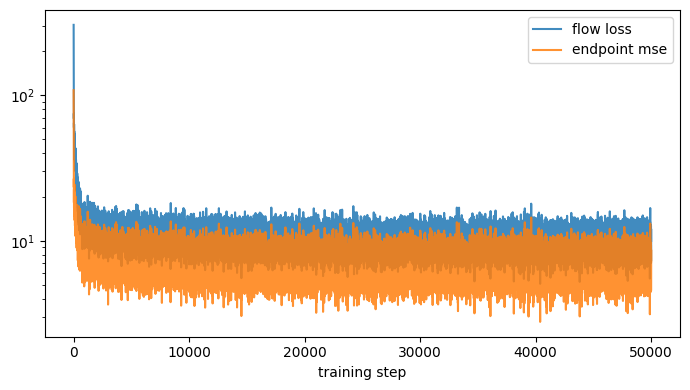

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history['flow_loss'], label='flow loss', alpha=0.85)
ax.plot(history['endpoint_mse'], label='endpoint mse', alpha=0.85)
ax.set_yscale('log')
ax.set_xlabel('training step')
ax.legend()
fig.tight_layout()


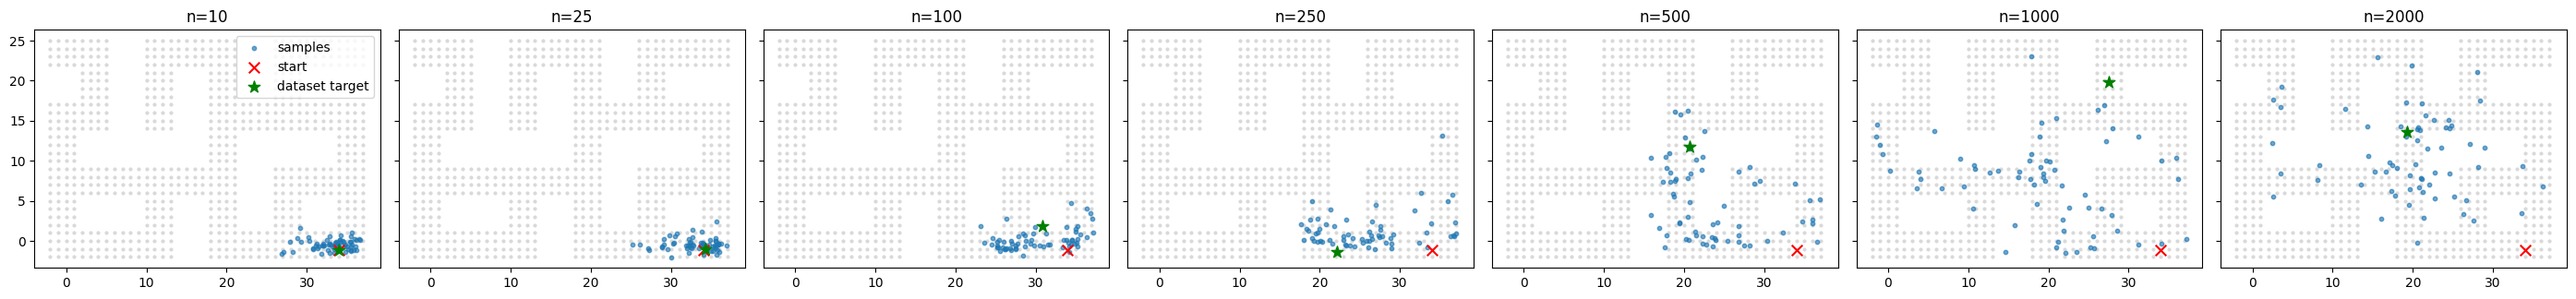

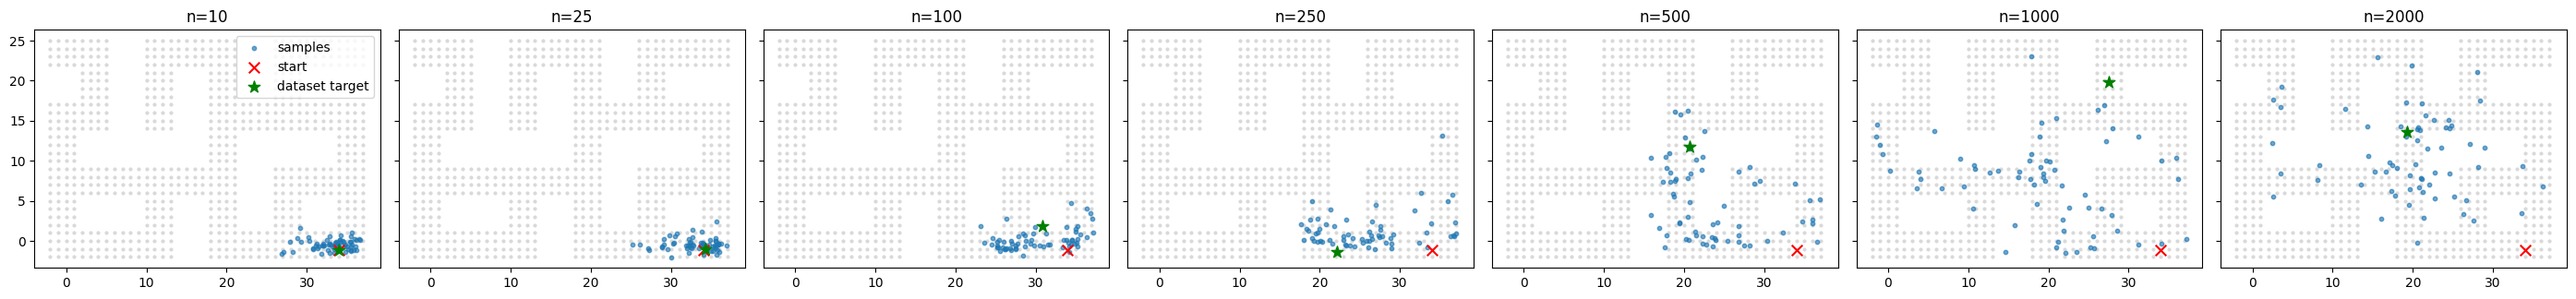

In [10]:
all_cells = {}
for ob in train_dataset.dataset['observations']:
    key = tuple(np.floor(ob[:2]))
    all_cells[key] = all_cells.get(key, 0) + 1
all_cell_points = np.asarray(list(all_cells.keys()))


def plot_horizon_samples(dataset, agent, idx, horizons=(10, 25, 100, 250, 500, 1000, 2000), num_samples=64, seed=0):
    idx = int(idx)
    rng = jax.random.PRNGKey(seed)
    observation = dataset.get_reps(np.asarray([idx]))[0]
    final_idx = dataset.terminal_locs[np.searchsorted(dataset.terminal_locs, idx)]

    fig, axes = plt.subplots(1, len(horizons), figsize=(4 * len(horizons), 4), sharex=True, sharey=True)
    if len(horizons) == 1:
        axes = [axes]

    for ax, horizon in zip(axes, horizons):
        target_idx = min(idx + int(horizon), int(final_idx))
        target = dataset.get_reps(np.asarray([target_idx]))[0]
        rng, sample_rng = jax.random.split(rng)
        samples = np.asarray(agent.sample_subgoals(observation, horizon, sample_rng, num_samples=num_samples))

        ax.scatter(all_cell_points[:, 0], all_cell_points[:, 1], s=4, c='0.85')
        ax.scatter(samples[:, 0], samples[:, 1], s=10, alpha=0.65, label='samples')
        ax.scatter(observation[0], observation[1], marker='x', s=70, c='red', label='start')
        ax.scatter(target[0], target[1], marker='*', s=90, c='green', label='dataset target')
        ax.set_title(f'n={horizon}')
        ax.set_aspect('equal', adjustable='box')

    axes[0].legend(loc='best')
    fig.tight_layout()
    return fig


valid_idx = int(train_dataset.dataset.get_random_idxs(1)[0])
plot_horizon_samples(train_dataset, agent, valid_idx, seed=config['seed'])


In [11]:
Path(config['output_dir']).mkdir(parents=True, exist_ok=True)
save_agent(agent, config['output_dir'], config['num_train_steps'])


Saved to checkpoints/horizon_subgoal_proposer/params_50000.pkl


## Training an unconditional goal proposer


This separate proposer learns the marginal distribution of state representations in the data. It is not conditioned on the current state, a goal, or a horizon `n`; sampling is just sampling from the learned training-state distribution.


In [12]:
unconditional_config = dict(config)
unconditional_config.update(
    output_dir='checkpoints/unconditional_goal_proposer_raw',
    num_train_steps=2_000_000,
    normalize_targets=False,
    norm_eps=1e-6,
)

unconditional_config.pop('min_horizon_steps', None)
unconditional_config.pop('max_horizon_steps', None)
unconditional_config.pop('goal_conditioned', None)
unconditional_config.pop('horizon_scale', None)

1000.0

In [13]:
@dataclass
class StateDistributionDataset:
    dataset: Any
    config: dict[str, Any]

    def __post_init__(self):
        self.size = self.dataset.size
        self.observations_key = self.config['observations_key']
        self.normalize_targets = bool(self.config.get('normalize_targets', False))
        self.norm_eps = float(self.config.get('norm_eps', 1e-6))

        reps = self.get_reps(np.arange(self.size, dtype=np.int64)).astype(np.float32)
        self.state_min = reps.min(axis=0)
        self.state_max = reps.max(axis=0)
        self.state_center = 0.5 * (self.state_min + self.state_max)
        self.state_half_range = np.maximum(0.5 * (self.state_max - self.state_min), self.norm_eps)

        self.config['state_min'] = self.state_min.tolist()
        self.config['state_max'] = self.state_max.tolist()
        self.config['state_center'] = self.state_center.tolist()
        self.config['state_half_range'] = self.state_half_range.tolist()

    def get_reps(self, idxs):
        if self.observations_key in self.dataset:
            return np.asarray(self.dataset[self.observations_key][idxs])
        return np.asarray(self.dataset['observations'][idxs])

    def normalize(self, states):
        states = np.asarray(states, dtype=np.float32)
        if not self.normalize_targets:
            return states
        return np.clip((states - self.state_center) / self.state_half_range, -1.0, 1.0)

    def unnormalize(self, normalized_states):
        normalized_states = np.asarray(normalized_states, dtype=np.float32)
        if not self.normalize_targets:
            return normalized_states
        return normalized_states * self.state_half_range + self.state_center

    def sample(self, batch_size: int, idxs=None):
        if idxs is None:
            idxs = self.dataset.get_random_idxs(batch_size)
        idxs = np.asarray(idxs, dtype=np.int64)
        raw_goals = self.get_reps(idxs).astype(np.float32)

        return dict(
            target_goals=raw_goals,
            raw_target_goals=raw_goals,
            idxs=idxs,
        )


In [14]:
class UnconditionalGoalVectorField(nn.Module):
    hidden_dims: tuple[int, ...]
    goal_dim: int
    layer_norm: bool = True

    @nn.compact
    def __call__(self, actions, times=None):
        inputs = [actions]
        if times is not None:
            inputs.append(times)

        x = jnp.concatenate(inputs, axis=-1)
        return MLP((*self.hidden_dims, self.goal_dim), activate_final=False, layer_norm=self.layer_norm)(x)


In [15]:
class UnconditionalGoalProposerAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def flow_loss(self, batch, grad_params=None, rng=None):
        target_goals = batch['target_goals']

        batch_size, goal_dim = target_goals.shape
        rng = self.rng if rng is None else rng
        x_rng, t_rng = jax.random.split(rng)

        x_0 = jax.random.normal(x_rng, (batch_size, goal_dim))
        t = jax.random.uniform(t_rng, (batch_size, 1))
        x_t = (1.0 - t) * x_0 + t * target_goals
        target_velocity = target_goals - x_0

        pred_velocity = self.network(
            actions=x_t,
            times=t,
            params=grad_params,
        )
        loss = jnp.mean(jnp.square(pred_velocity - target_velocity))
        mae = jnp.mean(jnp.abs(pred_velocity - target_velocity))
        endpoint_mse = jnp.mean(jnp.square((x_t + (1.0 - t) * pred_velocity) - target_goals))
        return loss, dict(flow_loss=loss, velocity_mae=mae, endpoint_mse=endpoint_mse)

    @jax.jit
    def update(self, batch):
        new_rng, loss_rng = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.flow_loss(batch, grad_params=grad_params, rng=loss_rng)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    def _sample_goals(self, rng, num_samples):
        x = jax.random.normal(rng, (num_samples, self.config['goal_dim']))
        for i in range(self.config['flow_steps']):
            t = jnp.full((num_samples, 1), i / self.config['flow_steps'])
            vels = self.network(actions=x, times=t)
            x = x + vels / self.config['flow_steps']
        return x

    def sample_goals(self, rng, num_samples=1):
        samples = self._sample_goals(rng, int(num_samples))
        if num_samples == 1:
            return samples[0]
        return samples

    @classmethod
    def create(cls, seed, example_batch, config):
        config = dict(config)
        rng = jax.random.PRNGKey(seed)
        rng, init_rng = jax.random.split(rng)
        goal_dim = example_batch['target_goals'].shape[-1]
        model = UnconditionalGoalVectorField(
            hidden_dims=tuple(config['hidden_dims']),
            goal_dim=goal_dim,
            layer_norm=bool(config['layer_norm']),
        )
        params = model.init(
            init_rng,
            actions=example_batch['target_goals'],
            times=jnp.zeros((example_batch['target_goals'].shape[0], 1)),
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        config['goal_dim'] = goal_dim
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))


In [16]:
unconditional_train_dataset = StateDistributionDataset(base_train_dataset, config=unconditional_config)
unconditional_example_batch = unconditional_train_dataset.sample(unconditional_config['batch_size'])
print('target goal batch:', unconditional_example_batch['target_goals'].shape)
print('raw target range:', unconditional_example_batch['target_goals'].min(axis=0), unconditional_example_batch['target_goals'].max(axis=0))
print('raw state min:', unconditional_train_dataset.state_min)
print('raw state max:', unconditional_train_dataset.state_max)

target goal batch: (256, 2)
normalized target range: [-0.9867096 -0.9937413] [0.9791978  0.97948164]
raw state min: [-1.9317689 -1.9303463]
raw state max: [37.93132  25.932753]


In [17]:
unconditional_agent = UnconditionalGoalProposerAgent.create(
    unconditional_config['seed'],
    unconditional_example_batch,
    unconditional_config,
)
jax.tree_util.tree_map(lambda x: x.shape, unconditional_agent.network.params)


{'MLP_0': {'Dense_0': {'bias': (256,), 'kernel': (3, 256)},
  'Dense_1': {'bias': (256,), 'kernel': (256, 256)},
  'Dense_2': {'bias': (256,), 'kernel': (256, 256)},
  'Dense_3': {'bias': (2,), 'kernel': (256, 2)},
  'LayerNorm_0': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_1': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_2': {'bias': (256,), 'scale': (256,)}}}

In [18]:
unconditional_history = dict(flow_loss=[], velocity_mae=[], endpoint_mse=[])

pbar = trange(1, unconditional_config['num_train_steps'] + 1)
for step in pbar:
    batch = unconditional_train_dataset.sample(unconditional_config['batch_size'])
    unconditional_agent, info = unconditional_agent.update(batch)

    for key in unconditional_history:
        unconditional_history[key].append(float(info[key]))

    if step == 1 or step % unconditional_config['log_interval'] == 0:
        pbar.set_description(
            f"loss={unconditional_history['flow_loss'][-1]:.4f} mae={unconditional_history['velocity_mae'][-1]:.4f}"
        )


loss=0.8651 mae=0.7255: 100%|██████████| 2000000/2000000 [56:30<00:00, 589.89it/s] 


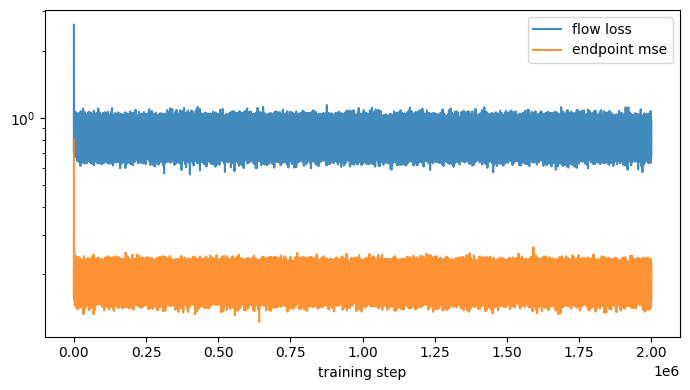

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(unconditional_history['flow_loss'], label='flow loss', alpha=0.85)
ax.plot(unconditional_history['endpoint_mse'], label='endpoint mse', alpha=0.85)
ax.set_yscale('log')
ax.set_xlabel('training step')
ax.legend()
fig.tight_layout()


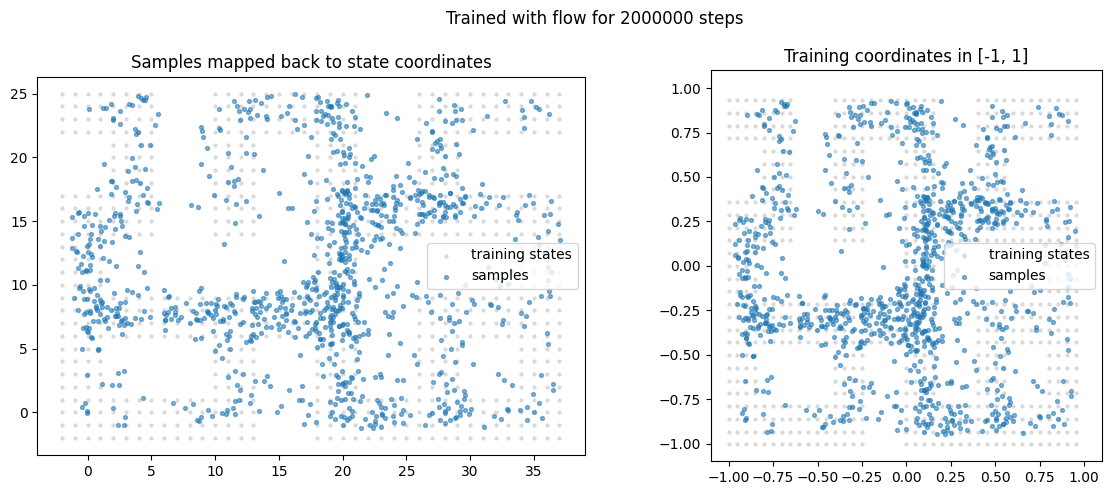

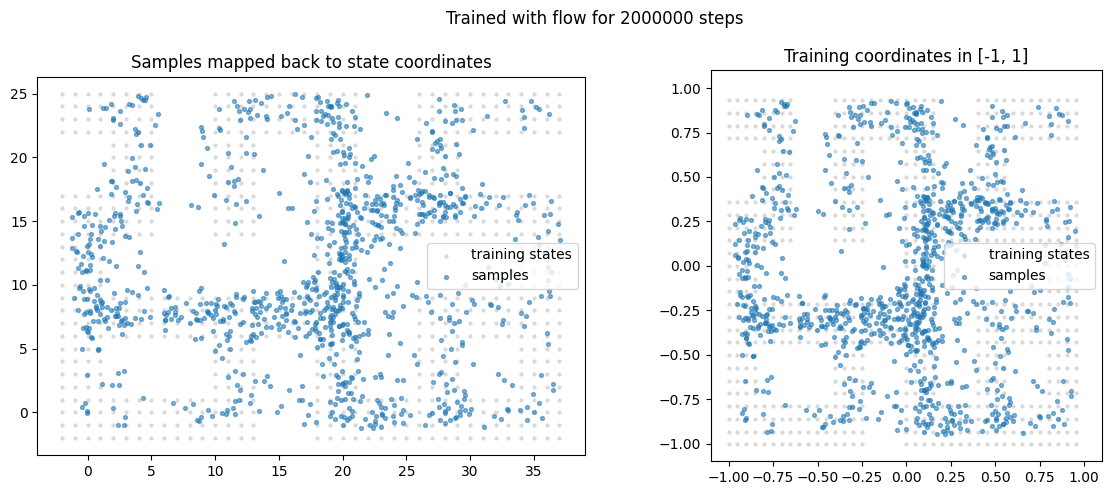

In [20]:
def plot_goal_samples(dataset, agent, num_samples=1024, seed=0):
    rng = jax.random.PRNGKey(seed)
    samples = np.asarray(agent.sample_goals(rng, num_samples=num_samples))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(all_cell_points[:, 0], all_cell_points[:, 1], s=4, c='0.85', label='training states')
    axes[0].scatter(samples[:, 0], samples[:, 1], s=8, alpha=0.55, label='samples')
    axes[0].set_aspect('equal', adjustable='box')
    axes[0].legend(loc='best')
    axes[0].set_title('Raw-space samples')

    axes[1].scatter(all_cell_points[:, 0], all_cell_points[:, 1], s=4, c='0.85', label='training states')
    axes[1].scatter(samples[:, 0], samples[:, 1], s=8, alpha=0.55, label='samples')
    axes[1].set_aspect('equal', adjustable='box')
    axes[1].legend(loc='best')
    axes[1].set_title('Training coordinates used by flow')

    fig.suptitle(f'Trained with flow for {unconditional_config["num_train_steps"]} steps')
    fig.tight_layout()
    return fig


plot_goal_samples(unconditional_train_dataset, unconditional_agent, seed=unconditional_config['seed'])

In [21]:
Path(unconditional_config['output_dir']).mkdir(parents=True, exist_ok=True)
save_agent(unconditional_agent, unconditional_config['output_dir'], unconditional_config['num_train_steps'])


Saved to checkpoints/unconditional_goal_proposer_normalized/params_2000000.pkl


## Implement Classifier-free guidance

## CFG IMPLEMENTATION APPENDED 2026-04-21 16:11:22

Run the code cell below after both `agent` and `unconditional_agent` exist. It implements classifier-free guidance at the end of the notebook only.

In [22]:
CFG_HELPERS_INSTALLED_AT_END = True
CFG_GUIDANCE_SCALE = 2.0


def _cfg_prepare_horizon_inputs(observations, horizons, goals=None, num_samples=1):
    observations = np.asarray(observations, dtype=np.float32)
    single_observation = observations.ndim == 1
    if single_observation:
        observations = np.repeat(observations[None], num_samples, axis=0)

    batch_size = observations.shape[0]
    horizons = np.asarray(horizons, dtype=np.float32)
    if horizons.ndim == 0:
        horizons = np.full((batch_size, 1), float(horizons), dtype=np.float32)
    elif horizons.ndim == 1:
        horizons = horizons[:, None]

    if goals is not None:
        goals = np.asarray(goals, dtype=np.float32)
        if goals.ndim == 1:
            goals = np.repeat(goals[None], batch_size, axis=0)

    return observations, horizons, goals, single_observation


@jax.jit
def _cfg_sample_horizon_subgoals(conditioned_agent, unconditioned_agent, observations, horizons, goals, rng, guidance_scale):
    x = jax.random.normal(rng, (observations.shape[0], conditioned_agent.config['subgoal_dim']))
    normalize_unconditioned = bool(unconditioned_agent.config.get('normalize_targets', False))
    state_center = jnp.asarray(
        unconditioned_agent.config.get('state_center', jnp.zeros(conditioned_agent.config['subgoal_dim'])),
        dtype=jnp.float32,
    )
    state_half_range = jnp.asarray(
        unconditioned_agent.config.get('state_half_range', jnp.ones(conditioned_agent.config['subgoal_dim'])),
        dtype=jnp.float32,
    )

    for i in range(conditioned_agent.config['flow_steps']):
        t = jnp.full((observations.shape[0], 1), i / conditioned_agent.config['flow_steps'])
        v_cond = conditioned_agent.network(observations, actions=x, horizons=horizons, goals=goals, times=t)

        if normalize_unconditioned:
            x_uncond = jnp.clip((x - state_center) / state_half_range, -1.0, 1.0)
            v_uncond = unconditioned_agent.network(actions=x_uncond, times=t) * state_half_range
        else:
            v_uncond = unconditioned_agent.network(actions=x, times=t)

        v_guided = v_uncond + guidance_scale * (v_cond - v_uncond)
        x = x + v_guided / conditioned_agent.config['flow_steps']

    return x


def sample_subgoals_cfg(conditioned_agent, unconditioned_agent, observations, horizons, rng, goals=None, num_samples=1, guidance_scale=CFG_GUIDANCE_SCALE):
    observations, horizons, goals, single_observation = _cfg_prepare_horizon_inputs(
        observations, horizons, goals=goals, num_samples=num_samples
    )
    samples = _cfg_sample_horizon_subgoals(
        conditioned_agent, unconditioned_agent, observations, horizons, goals, rng, float(guidance_scale)
    )
    if single_observation and num_samples == 1:
        return samples[0]
    return samples


def plot_horizon_samples_cfg(dataset, conditioned_agent, unconditioned_agent, idx, horizons=(10, 25, 100, 250, 500, 1000), num_samples=64, seed=0, guidance_scale=CFG_GUIDANCE_SCALE):
    idx = int(idx)
    rng = jax.random.PRNGKey(seed)
    observation = dataset.get_reps(np.asarray([idx]))[0]
    final_idx = dataset.terminal_locs[np.searchsorted(dataset.terminal_locs, idx)]

    fig, axes = plt.subplots(1, len(horizons), figsize=(4 * len(horizons), 4), sharex=True, sharey=True)
    if len(horizons) == 1:
        axes = [axes]

    for ax, horizon in zip(axes, horizons):
        target_idx = min(idx + int(horizon), int(final_idx))
        target = dataset.get_reps(np.asarray([target_idx]))[0]
        rng, sample_rng = jax.random.split(rng)
        samples = np.asarray(
            sample_subgoals_cfg(
                conditioned_agent,
                unconditioned_agent,
                observation,
                horizon,
                sample_rng,
                num_samples=num_samples,
                guidance_scale=guidance_scale,
            )
        )

        ax.scatter(all_cell_points[:, 0], all_cell_points[:, 1], s=4, c='0.85')
        ax.scatter(samples[:, 0], samples[:, 1], s=10, alpha=0.65, label='CFG samples')
        ax.scatter(observation[0], observation[1], marker='x', s=70, c='red', label='start')
        ax.scatter(target[0], target[1], marker='*', s=90, c='green', label='dataset target')
        ax.set_title(f'n={horizon}, cfg={guidance_scale:g}')
        ax.set_aspect('equal', adjustable='box')

    axes[0].legend(loc='best')
    fig.tight_layout()
    return fig


print('CFG installed at notebook end: sample_subgoals_cfg and plot_horizon_samples_cfg')
print('Example: plot_horizon_samples_cfg(train_dataset, agent, unconditional_agent, valid_idx, guidance_scale=2.0)')


CFG installed at notebook end: sample_subgoals_cfg and plot_horizon_samples_cfg
Example: plot_horizon_samples_cfg(train_dataset, agent, unconditional_agent, valid_idx, guidance_scale=2.0)


## Train CFG Proposers 2026-04-21 17:07:04

Train the current-xy/horizon-conditioned subgoal proposer and the unconditioned state proposer, then expose them as `agent` and `unconditional_agent` for CFG sampling.

unconditioned loss=0.8714 mae=0.7386: 100%|██████████| 50000/50000 [01:22<00:00, 602.50it/s]


Saved to checkpoints/horizon_subgoal_proposer/params_50000.pkl
Saved to checkpoints/unconditional_goal_proposer_normalized/params_50000.pkl


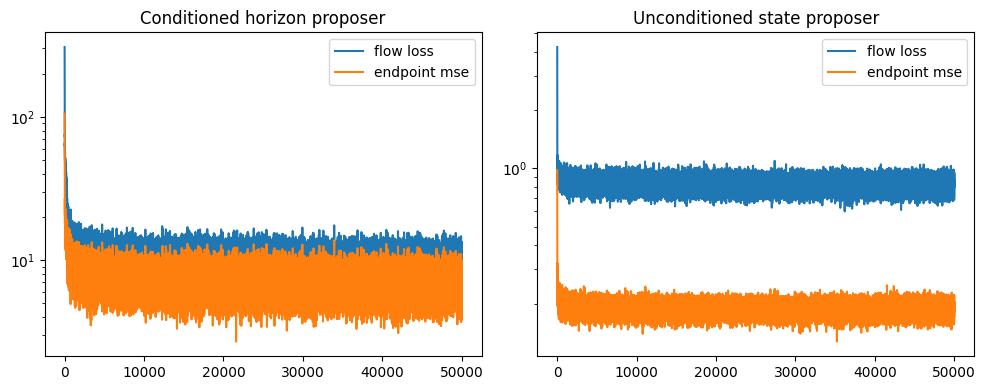

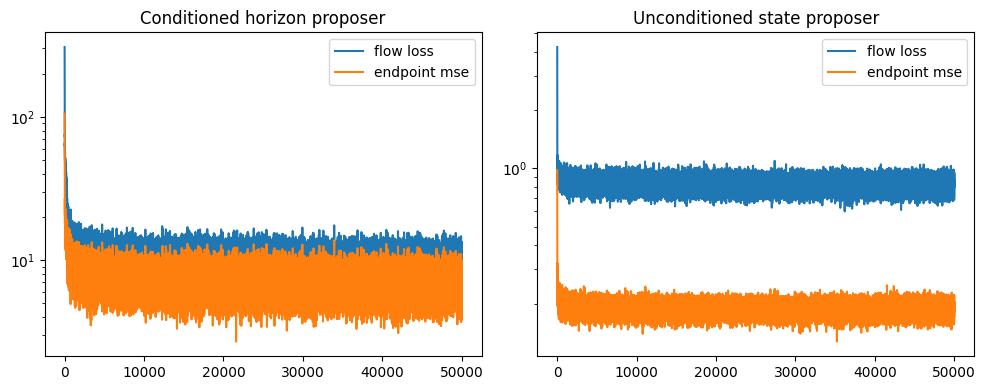

In [23]:
TRAIN_CFG_PROPOSERS_INSTALLED = True

# Training knobs. These default to the existing notebook config, but are collected here
# so the conditioned and unconditioned agents can be trained together before CFG visualization.
cfg_conditioned_train_steps = int(config.get('num_train_steps', 50_000))
cfg_unconditioned_train_steps = int(config.get('unconditional_num_train_steps', 50_000))
cfg_train_batch_size = int(config.get('batch_size', 256))
cfg_train_log_interval = int(config.get('log_interval', 500))
cfg_save_trained_agents = True

cfg_train_config = dict(config)
cfg_train_config.update(
    env_name=cfg_train_config.get('env_name', 'humanoidmaze-large-navigate-v0'),
    dataset_path=cfg_train_config.get(
        'dataset_path',
        '../../scratch/data/humanoidmaze-large-navigate-v0/humanoidmaze-large-navigate-v0seed-0.npz',
    ),
    observations_key=cfg_train_config.get('observations_key', 'oracle_reps'),
    hidden_dims=tuple(cfg_train_config.get('hidden_dims', (256, 256, 256))),
    layer_norm=bool(cfg_train_config.get('layer_norm', True)),
    lr=float(cfg_train_config.get('lr', 3e-4)),
    batch_size=cfg_train_batch_size,
    num_train_steps=cfg_conditioned_train_steps,
    log_interval=cfg_train_log_interval,
    seed=int(cfg_train_config.get('seed', 0)),
    min_horizon_steps=int(cfg_train_config.get('min_horizon_steps', 1)),
    max_horizon_steps=int(cfg_train_config.get('max_horizon_steps', cfg_train_config.get('subgoal_steps', 1000))),
    flow_steps=int(cfg_train_config.get('flow_steps', 10)),
    goal_conditioned=bool(cfg_train_config.get('goal_conditioned', False)),
    output_dir=cfg_train_config.get('output_dir', 'checkpoints/horizon_subgoal_proposer'),
)
cfg_train_config['horizon_scale'] = float(cfg_train_config['max_horizon_steps'])
config = cfg_train_config

# Rebuild the dataset objects used by both proposers. This keeps the cell runnable even
# if an earlier exploratory cell overwrote config or dataset variables.
env, base_train_dataset, val_dataset = make_env_and_datasets(
    config['env_name'],
    dataset_path=config['dataset_path'],
    use_oracle_reps=True,
)
train_dataset = HorizonSubgoalDataset(base_train_dataset, config=config)
example_batch = train_dataset.sample(config['batch_size'])

all_cells = {}
for ob in train_dataset.dataset['observations']:
    all_cells[tuple(np.floor(np.asarray(ob)[:2]))] = 1
all_cell_points = np.asarray(list(all_cells.keys()))


def train_horizon_conditioned_proposer(train_dataset, config, seed=None):
    seed = int(config['seed'] if seed is None else seed)
    example_batch = train_dataset.sample(config['batch_size'])
    trained_agent = HorizonSubgoalProposerAgent.create(seed, example_batch, config)
    train_history = dict(flow_loss=[], velocity_mae=[], endpoint_mse=[])

    pbar = trange(1, int(config['num_train_steps']) + 1, desc='conditioned proposer')
    for step in pbar:
        batch = train_dataset.sample(config['batch_size'])
        trained_agent, info = trained_agent.update(batch)
        for key in train_history:
            train_history[key].append(float(info[key]))
        if step == 1 or step % int(config['log_interval']) == 0:
            pbar.set_description(
                f"conditioned loss={train_history['flow_loss'][-1]:.4f} "
                f"mae={train_history['velocity_mae'][-1]:.4f}"
            )

    return trained_agent, train_history


def train_unconditioned_state_proposer(base_dataset, config, seed=None):
    uncond_config = dict(config)
    uncond_config.update(
        output_dir='checkpoints/unconditional_goal_proposer_raw',
        num_train_steps=cfg_unconditioned_train_steps,
        normalize_targets=False,
        norm_eps=float(uncond_config.get('norm_eps', 1e-6)),
        seed=int(config['seed'] if seed is None else seed),
    )
    for key in ('min_horizon_steps', 'max_horizon_steps', 'goal_conditioned', 'horizon_scale'):
        uncond_config.pop(key, None)

    uncond_dataset = StateDistributionDataset(base_dataset, config=uncond_config)
    uncond_example_batch = uncond_dataset.sample(uncond_config['batch_size'])
    trained_uncond_agent = UnconditionalGoalProposerAgent.create(
        uncond_config['seed'],
        uncond_example_batch,
        uncond_config,
    )
    uncond_history = dict(flow_loss=[], velocity_mae=[], endpoint_mse=[])

    pbar = trange(1, int(uncond_config['num_train_steps']) + 1, desc='unconditioned proposer')
    for step in pbar:
        batch = uncond_dataset.sample(uncond_config['batch_size'])
        trained_uncond_agent, info = trained_uncond_agent.update(batch)
        for key in uncond_history:
            uncond_history[key].append(float(info[key]))
        if step == 1 or step % int(config['log_interval']) == 0:
            pbar.set_description(
                f"unconditioned loss={uncond_history['flow_loss'][-1]:.4f} "
                f"mae={uncond_history['velocity_mae'][-1]:.4f}"
            )

    return trained_uncond_agent, uncond_dataset, uncond_config, uncond_history


# Train both agents and expose the names expected by the CFG helper/visualizer.
conditioned_agent, conditioned_history = train_horizon_conditioned_proposer(train_dataset, config)
agent = conditioned_agent

unconditional_agent, unconditional_train_dataset, unconditional_config, unconditional_history = train_unconditioned_state_proposer(
    base_train_dataset,
    config,
    seed=config['seed'] + 1,
)
unconditioned_agent = unconditional_agent
history = conditioned_history

if cfg_save_trained_agents:
    Path(config['output_dir']).mkdir(parents=True, exist_ok=True)
    save_agent(agent, config['output_dir'], config['num_train_steps'])
    Path(unconditional_config['output_dir']).mkdir(parents=True, exist_ok=True)
    save_agent(unconditional_agent, unconditional_config['output_dir'], unconditional_config['num_train_steps'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(conditioned_history['flow_loss'], label='flow loss')
axes[0].plot(conditioned_history['endpoint_mse'], label='endpoint mse')
axes[0].set_yscale('log')
axes[0].set_title('Conditioned horizon proposer')
axes[0].legend()
axes[1].plot(unconditional_history['flow_loss'], label='flow loss')
axes[1].plot(unconditional_history['endpoint_mse'], label='endpoint mse')
axes[1].set_yscale('log')
axes[1].set_title('Unconditioned state proposer')
axes[1].legend()
fig.tight_layout()
fig


In [ ]:
def checkpoint_current_proposers(
    conditioned_agent=None,
    unconditioned_agent=None,
    conditioned_dir=None,
    unconditioned_dir=None,
    checkpoint_suffix=None,
):
    conditioned_agent = agent if conditioned_agent is None else conditioned_agent
    unconditioned_agent = unconditional_agent if unconditioned_agent is None else unconditioned_agent

    conditioned_dir = Path(conditioned_dir or conditioned_agent.config.get('output_dir', config['output_dir']))
    unconditioned_dir = Path(
        unconditioned_dir
        or unconditioned_agent.config.get('output_dir', unconditional_config['output_dir'])
    )

    conditioned_step = int(conditioned_agent.network.step)
    unconditioned_step = int(unconditioned_agent.network.step)
    conditioned_epoch = checkpoint_suffix or f'current_step_{conditioned_step}'
    unconditioned_epoch = checkpoint_suffix or f'current_step_{unconditioned_step}'

    conditioned_dir.mkdir(parents=True, exist_ok=True)
    unconditioned_dir.mkdir(parents=True, exist_ok=True)

    save_agent(conditioned_agent, conditioned_dir, conditioned_epoch)
    save_agent(unconditioned_agent, unconditioned_dir, unconditioned_epoch)

    return dict(
        conditioned=str(conditioned_dir / f'params_{conditioned_epoch}.pkl'),
        unconditioned=str(unconditioned_dir / f'params_{unconditioned_epoch}.pkl'),
    )


checkpoint_paths = checkpoint_current_proposers()
checkpoint_paths


## CFG Subgoal Samples 2026-04-21 17:07:04

Use the trained conditioned and unconditioned agents above to visualize CFG-sampled subgoals. This does not use `dqc_agent` and does not step the environment.

In [28]:
subgoals.keys()

dict_keys(['target_goals', 'raw_target_goals', 'idxs'])

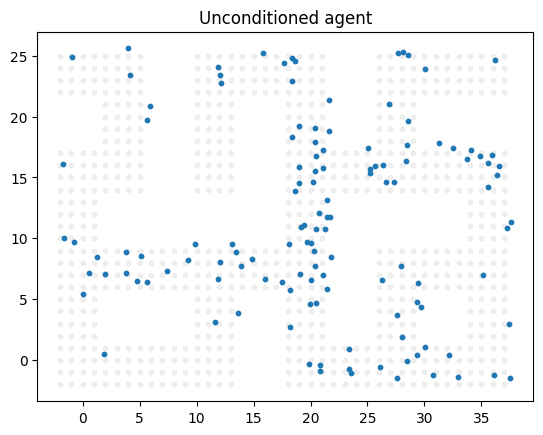

In [36]:
subgoals = unconditional_train_dataset.sample(128)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoals['raw_target_goals'][..., 0], y=subgoals['raw_target_goals'][..., 1], s=10)
# plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
# plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'Unconditioned agent')
plt.show()

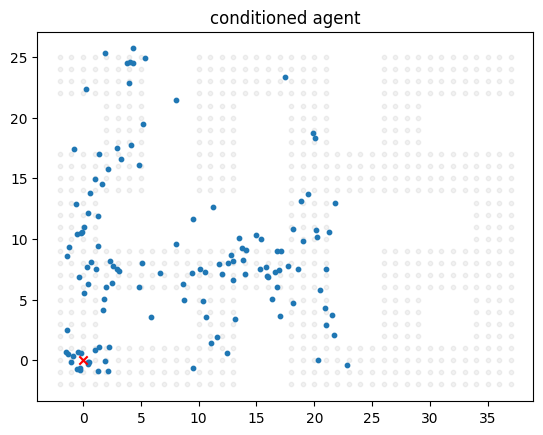

In [41]:
# subgoals = unconditional_train_dataset.sample(128)

start = np.asarray([0.0, 0.0])

rng = jax.random.PRNGKey(0)
sample_rng, rng = jax.random.split(rng)
subgoals = agent.sample_subgoals(start, 1000, sample_rng, num_samples=128)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=10)
# plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'conditioned agent')
plt.show()

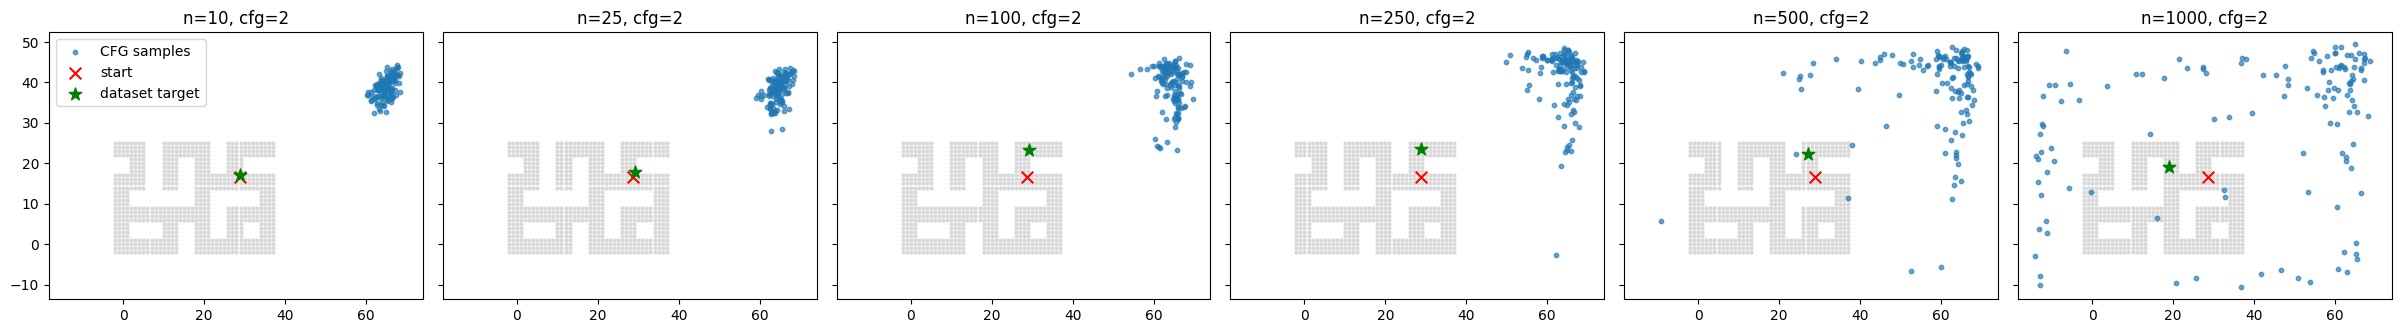

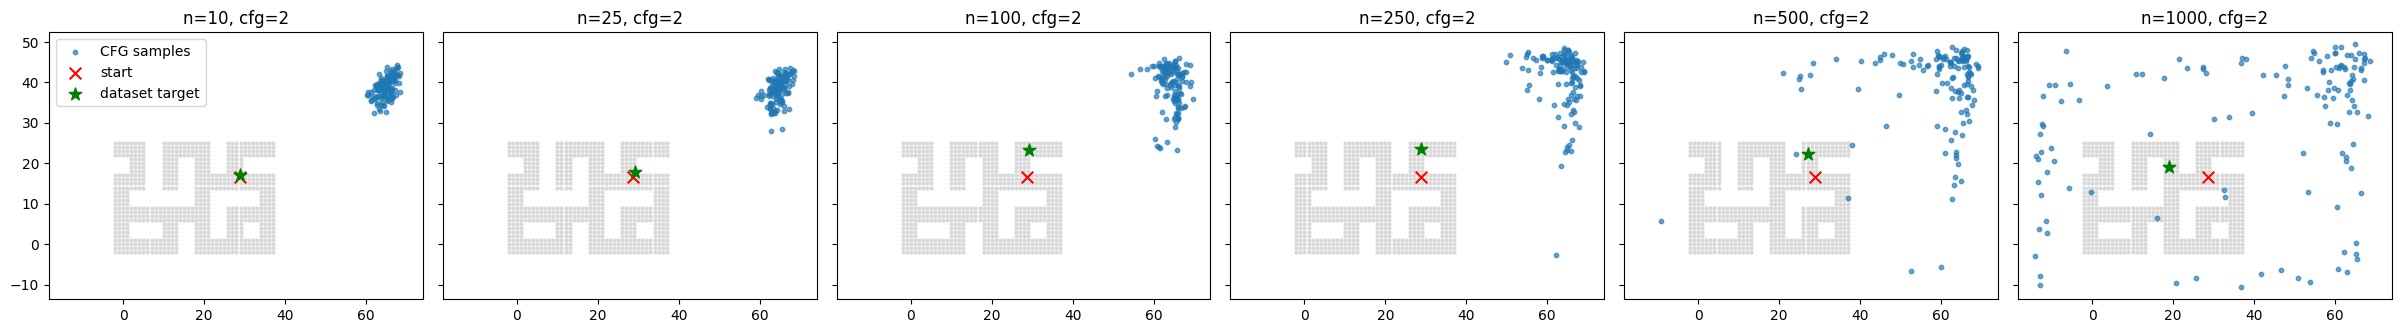

In [24]:
CFG_SUBGOAL_VIS_INSTALLED = True

# Visualization knobs.
cfg_vis_guidance_scale = 2.0
cfg_vis_horizons = (10, 25, 100, 250, 500, 1000)
cfg_vis_num_samples = 128
cfg_vis_seed = int(config.get('seed', 0)) + 20_000


def _require_cfg_subgoal_vis_names():
    missing = [
        name
        for name in ['train_dataset', 'agent', 'unconditional_agent', 'sample_subgoals_cfg']
        if name not in globals()
    ]
    if missing:
        raise NameError(
            'Missing required CFG subgoal visualization variables: '
            + ', '.join(missing)
            + '. Run the CFG helper cell and the Train CFG Proposers cell first.'
        )


def _cfg_all_cell_points(dataset):
    if 'all_cell_points' in globals():
        return all_cell_points
    cells = {}
    for ob in dataset.dataset['observations']:
        cells[tuple(np.floor(np.asarray(ob)[:2]))] = 1
    return np.asarray(list(cells.keys()))


def plot_cfg_subgoal_samples(
    dataset=None,
    conditioned_agent=None,
    unconditioned_agent=None,
    idx=None,
    horizons=cfg_vis_horizons,
    num_samples=cfg_vis_num_samples,
    seed=cfg_vis_seed,
    guidance_scale=cfg_vis_guidance_scale,
):
    _require_cfg_subgoal_vis_names()
    dataset = train_dataset if dataset is None else dataset
    conditioned_agent = agent if conditioned_agent is None else conditioned_agent
    unconditioned_agent = unconditional_agent if unconditioned_agent is None else unconditioned_agent

    if idx is None:
        idx = int(dataset.dataset.get_random_idxs(1)[0])
    idx = int(idx)

    rng = jax.random.PRNGKey(seed)
    observation = dataset.get_reps(np.asarray([idx]))[0]
    final_idx = dataset.terminal_locs[np.searchsorted(dataset.terminal_locs, idx)]
    points = _cfg_all_cell_points(dataset)

    fig, axes = plt.subplots(1, len(horizons), figsize=(4 * len(horizons), 4), sharex=True, sharey=True)
    if len(horizons) == 1:
        axes = [axes]

    sampled_by_horizon = {}
    for ax, horizon in zip(axes, horizons):
        target_idx = min(idx + int(horizon), int(final_idx))
        target = dataset.get_reps(np.asarray([target_idx]))[0]
        rng, sample_rng = jax.random.split(rng)
        samples = np.asarray(
            sample_subgoals_cfg(
                conditioned_agent,
                unconditioned_agent,
                observation,
                horizon,
                sample_rng,
                num_samples=num_samples,
                guidance_scale=guidance_scale,
            )
        )
        sampled_by_horizon[int(horizon)] = samples

        ax.scatter(points[:, 0], points[:, 1], s=4, c='0.85')
        ax.scatter(samples[:, 0], samples[:, 1], s=10, alpha=0.65, label='CFG samples')
        ax.scatter(observation[0], observation[1], marker='x', s=70, c='red', label='start')
        ax.scatter(target[0], target[1], marker='*', s=90, c='green', label='dataset target')
        ax.set_title(f'n={horizon}, cfg={guidance_scale:g}')
        ax.set_aspect('equal', adjustable='box')

    axes[0].legend(loc='best')
    fig.tight_layout()
    return fig, sampled_by_horizon


cfg_subgoal_fig, cfg_subgoal_samples = plot_cfg_subgoal_samples()
cfg_subgoal_fig


In [46]:
class GCFlowGoalProposerAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def _get_horizons(self, batch, batch_size):
        if not self.config['horizon_conditioned']:
            return None

        horizon_key = self.config.get('horizon_key', 'horizons')
        if horizon_key in batch:
            horizons = jnp.asarray(batch[horizon_key], dtype=jnp.float32)
        else:
            horizons = jnp.full((batch_size, 1), float(self.config['subgoal_steps']), dtype=jnp.float32)
        if horizons.ndim == 1:
            horizons = horizons[:, None]
        return horizons

    def _encode_horizons(self, horizons):
        horizon_scale = float(self.config.get('horizon_scale', self.config.get('subgoal_steps', 1)))
        horizons = jnp.asarray(horizons, dtype=jnp.float32)
        if horizons.ndim == 1:
            horizons = horizons[:, None]
        linear = horizons / horizon_scale
        log_linear = jnp.log1p(horizons) / jnp.log1p(horizon_scale)
        return jnp.concatenate([linear, log_linear], axis=-1)

    def _append_horizons(self, observations, horizons):
        if not self.config['horizon_conditioned']:
            return observations
        return jnp.concatenate([observations, self._encode_horizons(horizons)], axis=-1)

    def flow_loss(self, batch, grad_params=None, rng=None):
        target_actions = jnp.asarray(batch[self.config['actions_key']], dtype=jnp.float32)
        batch_size, action_dim = target_actions.shape

        if self.config['observation_conditioned']:
            observations = jnp.asarray(batch[self.config['observations_key']], dtype=jnp.float32)
        else:
            observations = jnp.zeros((batch_size, 0), dtype=jnp.float32)

        horizons = self._get_horizons(batch, batch_size)
        observations = self._append_horizons(observations, horizons)

        goals = batch[self.config['goal_key']] if self.config['goal_conditioned'] else None
        goals = None if goals is None else jnp.asarray(goals, dtype=jnp.float32)

        rng = self.rng if rng is None else rng
        x_rng, t_rng = jax.random.split(rng)

        x_0 = jax.random.normal(x_rng, (batch_size, action_dim))
        t = jax.random.uniform(t_rng, (batch_size, 1))
        x_t = (1.0 - t) * x_0 + t * target_actions
        vel = target_actions - x_0

        pred_vel = self.network(
            observations,
            goals=goals,
            actions=x_t,
            times=t,
            params=grad_params,
        )
        loss = jnp.mean(jnp.square(pred_vel - vel))
        mae = jnp.mean(jnp.abs(pred_vel - vel))
        endpoint_mse = jnp.mean(jnp.square((x_t + (1.0 - t) * pred_vel) - target_actions))
        return loss, {
            'flow_loss': loss,
            'velocity_mae': mae,
            'endpoint_mse': endpoint_mse,
        }

    @jax.jit
    def update(self, batch):
        new_rng, rng = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.flow_loss(batch, grad_params, rng=rng)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    @jax.jit
    def _sample_actions(self, observations, goals, rng):
        x = jax.random.normal(rng, (observations.shape[0], self.config['action_dim']))

        for i in range(self.config['flow_steps']):
            t = jnp.full((observations.shape[0], 1), i / self.config['flow_steps'])
            vels = self.network(observations, goals=goals, actions=x, times=t)
            x = x + vels / self.config['flow_steps']

        return x

    def sample_actions(self, observations=None, goals=None, rng=None, num_samples=None, horizons=None):
        if rng is None:
            rng = self.rng

        if self.config['observation_conditioned']:
            if observations is None:
                raise ValueError('observations are required when observation_conditioned=True')
            observations = np.asarray(observations, dtype=np.float32)
            single_example = observations.ndim == 1
            if single_example:
                observations = observations[None, ...]
            return_single = single_example and num_samples is None
        else:
            if num_samples is not None:
                batch_size = int(num_samples)
            elif goals is not None and np.asarray(goals).ndim > 1:
                batch_size = int(np.asarray(goals).shape[0])
            elif observations is not None and np.asarray(observations).ndim > 1:
                batch_size = int(np.asarray(observations).shape[0])
            elif horizons is not None and np.asarray(horizons).ndim > 0:
                batch_size = int(np.asarray(horizons).shape[0])
            else:
                batch_size = 1
            observations = np.zeros((batch_size, 0), dtype=np.float32)
            single_example = batch_size == 1
            return_single = single_example and num_samples is None

        if self.config['horizon_conditioned']:
            if horizons is None:
                horizons = np.full((observations.shape[0], 1), float(self.config['subgoal_steps']), dtype=np.float32)
            else:
                horizons = np.asarray(horizons, dtype=np.float32)
                if horizons.ndim == 0:
                    horizons = np.full((observations.shape[0], 1), float(horizons), dtype=np.float32)
                elif horizons.ndim == 1:
                    horizons = horizons[:, None]
                if horizons.shape[0] == 1 and observations.shape[0] != 1:
                    horizons = np.repeat(horizons, observations.shape[0], axis=0)
                elif horizons.shape[0] != observations.shape[0]:
                    raise ValueError(
                        f"horizons batch size must match observations batch size: "
                        f"{horizons.shape[0]} vs {observations.shape[0]}"
                    )
            observations = np.asarray(self._append_horizons(observations, horizons), dtype=np.float32)

        if not self.config['goal_conditioned']:
            goals = None
        elif goals is None:
            raise ValueError('goals are required when goal_conditioned=True')
        elif goals is not None:
            goals = np.asarray(goals, dtype=np.float32)
            if goals.ndim == 1:
                goals = goals[None, ...]

            if single_example and goals.shape[0] != observations.shape[0]:
                observations = np.repeat(observations, goals.shape[0], axis=0)
                return_single = False
            elif goals.shape[0] != observations.shape[0]:
                raise ValueError(
                    f"goals batch size must match observations batch size: {goals.shape[0]} vs {observations.shape[0]}"
                )

        x = self._sample_actions(observations, goals, rng)
        return x[0] if return_single else x

    @classmethod
    def create(cls, example_batch, config, seed=None):
        config = dict(config)
        config.setdefault('goal_conditioned', True)
        config.setdefault('observation_conditioned', True)
        config.setdefault('horizon_conditioned', False)
        config.setdefault('horizon_key', 'horizons')
        config.setdefault('horizon_scale', config.get('subgoal_steps', 1))
        seed = int(config.get('seed', 0) if seed is None else seed)
        rng = jax.random.PRNGKey(seed)
        rng, init_rng = jax.random.split(rng)
        action_dim = example_batch[config['actions_key']].shape[-1]
        model = ActorVectorField(
            hidden_dims=tuple(config['hidden_dims']),
            action_dim=action_dim,
            layer_norm=config['layer_norm'],
        )
        init_goals = example_batch[config['goal_key']] if config['goal_conditioned'] else None
        init_observations = (
            example_batch[config['observations_key']]
            if config['observation_conditioned']
            else jnp.zeros((*example_batch[config['actions_key']].shape[:-1], 0), dtype=jnp.float32)
        )
        if config['horizon_conditioned']:
            batch_size = example_batch[config['actions_key']].shape[0]
            if config['horizon_key'] in example_batch:
                init_horizons = jnp.asarray(example_batch[config['horizon_key']], dtype=jnp.float32)
            else:
                init_horizons = jnp.full((batch_size, 1), float(config['subgoal_steps']), dtype=jnp.float32)
            if init_horizons.ndim == 1:
                init_horizons = init_horizons[:, None]
            horizon_scale = float(config['horizon_scale'])
            horizon_features = jnp.concatenate(
                [
                    init_horizons / horizon_scale,
                    jnp.log1p(init_horizons) / jnp.log1p(horizon_scale),
                ],
                axis=-1,
            )
            init_observations = jnp.concatenate([init_observations, horizon_features], axis=-1)
        params = model.init(
            init_rng,
            init_observations,
            goals=init_goals,
            actions=example_batch[config['actions_key']],
            times=jnp.zeros_like(example_batch[config['actions_key']][..., :1]),
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        config['action_dim'] = action_dim
        config['seed'] = seed
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))



## Train three goal proposer variants

In [53]:
from utils.datasets import CGCDataset
from utils.networks import ActorVectorField

In [54]:
THREE_WAY_TRAIN_STEPS = 3_000_000
THREE_WAY_FIXED_HORIZON = 100
THREE_WAY_MIN_HORIZON = 1
THREE_WAY_MAX_HORIZON = 100
THREE_WAY_BATCH_SIZE = int(config.get('batch_size', 256))
THREE_WAY_LOG_INTERVAL = int(config.get('log_interval', 1_000))
THREE_WAY_SAVE_INTERVAL = 250_000


class GoalProposerCGCDataset(CGCDataset):
    def sample(self, batch_size: int, idxs=None, evaluation=False):
        if idxs is None:
            idxs = self.dataset.get_random_idxs(batch_size)

        if not self.config.get('horizon_conditioned', False):
            return super().sample(batch_size, idxs=idxs, evaluation=evaluation)

        batch = self.dataset.sample(batch_size, idxs)
        final_state_idxs = self.terminal_locs[np.searchsorted(self.terminal_locs, idxs)]
        min_horizon = int(self.config.get('min_horizon_steps', 1))
        max_horizon = int(self.config.get('max_horizon_steps', self.config['subgoal_steps']))
        horizons = np.random.randint(min_horizon, max_horizon + 1, size=batch_size)
        target_idxs = np.minimum(idxs + horizons, final_state_idxs)

        if 'oracle_reps' in self.dataset:
            batch[self.config['actions_key']] = self.dataset['oracle_reps'][target_idxs]
        else:
            batch[self.config['actions_key']] = self.get_observations(target_idxs)

        if self.config.get('goal_conditioned', False):
            actor_goal_idxs = self.sample_goals(
                idxs,
                self.config['actor_p_curgoal'],
                self.config['actor_p_trajgoal'],
                self.config['actor_p_randomgoal'],
                self.config['actor_geom_sample'],
            )
            if 'oracle_reps' in self.dataset:
                batch[self.config['goal_key']] = self.dataset['oracle_reps'][actor_goal_idxs]
            else:
                batch[self.config['goal_key']] = self.get_observations(actor_goal_idxs)

        batch[self.config['horizon_key']] = horizons[:, None].astype(np.float32)
        return batch


def make_goal_proposer_config(name, *, observation_conditioned, horizon_conditioned, seed_offset=0):
    proposer_config = dict(config)
    proposer_config.update(
        output_dir=f'checkpoints/gc_flow_goal_proposer/{name}',
        num_train_steps=THREE_WAY_TRAIN_STEPS,
        batch_size=THREE_WAY_BATCH_SIZE,
        log_interval=THREE_WAY_LOG_INTERVAL,
        seed=int(config.get('seed', 0)) + int(seed_offset),
        actions_key='low_actor_goals',
        value_p_curgoal=0.0,
        value_p_trajgoal=1.0,
        value_p_randomgoal=0.0,
        value_geom_sample=False,
        actor_p_curgoal=0.0,
        actor_p_trajgoal=1.0,
        actor_p_randomgoal=0.0,
        actor_geom_sample=True,
        gc_negative=False,
        discount=float(config.get('discount', 0.995)),
        backup_horizon=int(config.get('backup_horizon', 25)),
        goal_conditioned=False,
        observation_conditioned=bool(observation_conditioned),
        horizon_conditioned=bool(horizon_conditioned),
        horizon_key='horizons',
        min_horizon_steps=THREE_WAY_MIN_HORIZON,
        max_horizon_steps=THREE_WAY_MAX_HORIZON,
        subgoal_steps=THREE_WAY_FIXED_HORIZON,
        horizon_scale=float(THREE_WAY_MAX_HORIZON),
    )
    return proposer_config


def train_gc_flow_goal_proposer_variant(name, proposer_config, base_dataset):
    dataset = GoalProposerCGCDataset(base_dataset, config=proposer_config)
    example_batch = dataset.sample(proposer_config['batch_size'])
    agent = GCFlowGoalProposerAgent.create(example_batch, proposer_config, seed=proposer_config['seed'])
    history = dict(flow_loss=[], velocity_mae=[], endpoint_mse=[])

    output_dir = Path(proposer_config['output_dir'])
    output_dir.mkdir(parents=True, exist_ok=True)

    pbar = trange(1, proposer_config['num_train_steps'] + 1, desc=name)
    for step in pbar:
        batch = dataset.sample(proposer_config['batch_size'])
        agent, info = agent.update(batch)

        for key in history:
            history[key].append(float(info[key]))

        if step == 1 or step % proposer_config['log_interval'] == 0:
            pbar.set_description(
                f"{name} loss={history['flow_loss'][-1]:.4f} "
                f"mae={history['velocity_mae'][-1]:.4f} "
                f"endpoint={history['endpoint_mse'][-1]:.4f}"
            )

        if THREE_WAY_SAVE_INTERVAL and step % THREE_WAY_SAVE_INTERVAL == 0:
            save_agent(agent, str(output_dir), step)

    save_agent(agent, str(output_dir), proposer_config['num_train_steps'])
    return agent, dataset, history


three_way_base_config = dict(config)
three_way_base_config.update(
    env_name=three_way_base_config.get('env_name', 'humanoidmaze-giant-navigate-v0'),
    dataset_path=three_way_base_config.get(
        'dataset_path',
        '../../scratch/data/humanoidmaze-giant-navigate-v0/humanoidmaze-giant-navigate-100m-v0/humanoidmaze-giant-navigate-v0-003.npz',
    ),
    observations_key=three_way_base_config.get('observations_key', 'oracle_reps'),
    goal_key=three_way_base_config.get('goal_key', 'actor_goals'),
)
config = three_way_base_config

env, base_train_dataset, val_dataset = make_env_and_datasets(
    config['env_name'],
    dataset_path=config['dataset_path'],
    use_oracle_reps=True,
)

three_way_specs = {
    'unconditioned_h100': make_goal_proposer_config(
        'unconditioned_h100',
        observation_conditioned=False,
        horizon_conditioned=False,
        seed_offset=0,
    ),
    'observation_h100': make_goal_proposer_config(
        'observation_h100',
        observation_conditioned=True,
        horizon_conditioned=False,
        seed_offset=1,
    ),
    'observation_horizon_h1_100': make_goal_proposer_config(
        'observation_horizon_h1_100',
        observation_conditioned=True,
        horizon_conditioned=True,
        seed_offset=2,
    ),
}

three_way_agents = {}
three_way_datasets = {}
three_way_histories = {}

for name, proposer_config in three_way_specs.items():
    agent_i, dataset_i, history_i = train_gc_flow_goal_proposer_variant(
        name,
        proposer_config,
        base_train_dataset,
    )
    three_way_agents[name] = agent_i
    three_way_datasets[name] = dataset_i
    three_way_histories[name] = history_i

unconditioned_h100_agent = three_way_agents['unconditioned_h100']
observation_h100_agent = three_way_agents['observation_h100']
observation_horizon_agent = three_way_agents['observation_horizon_h1_100']


unconditioned_h100 loss=14.8269 mae=2.3731 endpoint=11.6417:   8%|▊         | 250062/3000000 [13:03<2:06:07, 363.41it/s]

Saved to checkpoints/gc_flow_goal_proposer/unconditioned_h100/params_250000.pkl


unconditioned_h100 loss=12.2103 mae=2.2478 endpoint=8.4237:  17%|█▋        | 500030/3000000 [27:19<3:11:03, 218.08it/s] 

Saved to checkpoints/gc_flow_goal_proposer/unconditioned_h100/params_500000.pkl


unconditioned_h100 loss=11.9539 mae=2.1209 endpoint=8.8221:  25%|██▌       | 750022/3000000 [46:17<2:56:11, 212.84it/s] 

...

Saved to checkpoints/gc_flow_goal_proposer/observation_horizon_h1_100/params_2500000.pkl


observation_horizon_h1_100 loss=2.7619 mae=1.1235 endpoint=1.4633:  92%|█████████▏| 2750051/3000000 [1:35:18<08:42, 478.46it/s]

Saved to checkpoints/gc_flow_goal_proposer/observation_horizon_h1_100/params_2750000.pkl


observation_horizon_h1_100 loss=2.7289 mae=1.1673 endpoint=1.3042: 100%|██████████| 3000000/3000000 [1:43:55<00:00, 481.12it/s]

Saved to checkpoints/gc_flow_goal_proposer/observation_horizon_h1_100/params_3000000.pkl
Saved to checkpoints/gc_flow_goal_proposer/observation_horizon_h1_100/params_3000000.pkl


In [1]:
print('test')

test


## Training conditioned on observation

In [ ]:
dataset

NameError: name 'dataset' is not defined

In [ ]:
config = dict(
    env_name='humanoidmaze-giant-navigate-v0',
    # dataset_path='../../scratch/aorl2/YOUR_RUN_DIR/data-1000000.npz',
    dataset_path='../../scratch/data/humanoidmaze-giant-navigate-v0/humanoidmaze-giant-navigate-100m-v0/humanoidmaze-giant-navigate-v0-003.npz',
    observations_key='oracle_reps', # 'observations',
    goal_key='actor_goals',
    actions_key='low_actor_goals', #'actions',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    batch_size=256,
    num_train_steps=args['num_train_steps'],
    log_interval=100,
    seed=args['seed'],
    value_p_curgoal=0.0,
    value_p_trajgoal=1.0,
    value_p_randomgoal=0.0,
    value_geom_sample=False,
    actor_p_curgoal=0.0,
    actor_p_trajgoal=1.0,
    actor_p_randomgoal=0.0,
    actor_geom_sample=True,
    gc_negative=False,
    subgoal_steps=args['subgoal_steps'],
    discount=0.995,
    flow_steps=10,
    backup_horizon=25,
    goal_conditioned=False,
    observation_conditioned=False,
    horizon_conditioned=False,
    horizon_key='horizons',
    horizon_scale=args['subgoal_steps'],
)

In [ ]:
##=========== TRAIN GOAL PROPOSER ===========##

example_batch = train_dataset.sample(1)
flow_agent = GCFlowGoalProposerAgent.create(example_batch, config)
jax.tree_util.tree_map(lambda x: x.shape, flow_agent.network.params)

flow_loss_history = []
velocity_mae_history = []
endpoint_mse_history = []

for step in range(1, config['num_train_steps'] + 1):
    batch = train_dataset.sample(config['batch_size'])
    flow_agent, info = flow_agent.update(batch)

    flow_loss_history.append(float(info['flow_loss']))
    velocity_mae_history.append(float(info['velocity_mae']))
    endpoint_mse_history.append(float(info['endpoint_mse']))

    if step == 1 or step % config['log_interval'] == 0:
        log_wandb(
            {
                'goal_proposer/flow_loss': float(info['flow_loss']),
                'goal_proposer/velocity_mae': float(info['velocity_mae']),
                'goal_proposer/endpoint_mse': float(info['endpoint_mse']),
            },
            step=step,
        )
        print(
            f"step={step:05d} flow_loss={flow_loss_history[-1]:.6f} "
            f"velocity_mae={velocity_mae_history[-1]:.6f} endpoint_mse={endpoint_mse_history[-1]:.6f}"
        )